# Release benchmark: two-stage pipelines and lazy composition

This notebook measures every ordered pair of Parametric Star, Edge BPE, and
Named Vertex on near-binary and near-star trees. For each row it:

1. fits stage 1 on the raw tree;
2. transforms once to construct the stage-2 fit corpus;
3. fits stage 2 on that encoded tree;
4. times manual sequential transform and reverse-order decode;
5. times the equivalent `combine(...)` encoder and decoder;
6. asserts exact encoded equality, exact raw round trips, correct stage order,
   and caller-input nonmutation.

The stage-2 preparation transform is reported separately because it is a real
cost of fitting a sequential pipeline, but it is not part of steady-state
application after both stages are fitted.


## 0. Imports and repository checkout


In [1]:
from __future__ import annotations

import gc
import json
import os
import random
import sys
from itertools import permutations
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "tree_coarsening").is_dir():
            return candidate
    raise RuntimeError("Could not locate the tree-coarsening repository root.")


ROOT = find_project_root(Path.cwd())
BENCHMARK_DIR = ROOT / "benchmarks"

for entry in (str(ROOT), str(BENCHMARK_DIR)):
    if entry not in sys.path:
        sys.path.insert(0, entry)

from benchmark_common import (  # noqa: E402
    encoded_signature,
    environment_metadata,
    make_benchmark_tree,
    make_coarsener,
    method_display_name,
    raw_signature,
    warm_numba_backend,
)
from tree_coarsening import SCHEMA_KEY, combine  # noqa: E402

ENVIRONMENT = environment_metadata(ROOT)
ENVIRONMENT

{'python': '3.13.13',
 'python_implementation': 'CPython',
 'python_executable': '<PYTHON_EXECUTABLE>',
 'platform': 'Linux-6.17.0-1025-oem-x86_64-with-glibc2.39',
 'processor': 'x86_64',
 'logical_cpu_count': 24,
 'networkx': '3.6.1',
 'tree_coarsening': '0.11.0',
 'git_commit': 'unknown',
 'numpy': '2.4.6',
 'numba': '0.65.1',
 'physical_memory_bytes': 134489358336}

## 1. Controls

The default uses the Python BPE backend so composition timing is not dominated
by a one-time compiler event. Set `BPE_METHOD = "bpe_numba"` to measure warmed
Numba pipelines; the notebook will explicitly warm that backend first.


In [2]:
PROFILES = {
    "smoke": {"sizes": (63, 127), "repeats": 1},
    "standard": {"sizes": (250, 500, 1_000, 2_000, 4_000), "repeats": 3},
    "extended": {"sizes": (500, 1_000, 2_000, 4_000, 8_000, 16_000), "repeats": 5},
}

PROFILE = os.environ.get("TREE_COARSENING_BENCH_PROFILE", "standard")
if PROFILE not in PROFILES:
    raise ValueError(f"Unknown benchmark profile {PROFILE!r}; choose from {tuple(PROFILES)}")

SIZES = PROFILES[PROFILE]["sizes"]
REPEATS = PROFILES[PROFILE]["repeats"]
SHAPES = ("near_binary", "near_star")
BPE_METHOD = "bpe_python"  # change to "bpe_numba" for a warmed Numba pipeline sweep
ATOMIC_METHODS = ("star", BPE_METHOD, "named")
PIPELINES = tuple(permutations(ATOMIC_METHODS, 2))
VALIDATE = "full"
PIPELINE_BPE_NUM_MERGES = 8
BPE_MIN_PAIR_COUNT = 2
SAVE_RESULTS = True
TASK_ORDER_SEED = 20260621

{
    "profile": PROFILE,
    "sizes": SIZES,
    "repeats": REPEATS,
    "shapes": SHAPES,
    "pipelines": PIPELINES,
    "validate": VALIDATE,
    "bpe_method": BPE_METHOD,
}

{'profile': 'extended',
 'sizes': (500, 1000, 2000, 4000, 8000, 16000),
 'repeats': 5,
 'shapes': ('near_binary', 'near_star'),
 'pipelines': (('star', 'bpe_python'),
  ('star', 'named'),
  ('bpe_python', 'star'),
  ('bpe_python', 'named'),
  ('named', 'star'),
  ('named', 'bpe_python')),
 'validate': 'full',
 'bpe_method': 'bpe_python'}

## 2. Corpora and optional backend warm-up


In [3]:
corpora = {
    (shape, n_nodes): make_benchmark_tree(shape, n_nodes, seed=TASK_ORDER_SEED + n_nodes)
    for shape in SHAPES
    for n_nodes in SIZES
}
raw_signatures = {key: raw_signature(graph) for key, graph in corpora.items()}

numba_cold_seconds = None
if BPE_METHOD == "bpe_numba":
    numba_cold_seconds = warm_numba_backend(validate=False)

{
    "corpora": len(corpora),
    "numba_cold_warmup_seconds": numba_cold_seconds,
    "largest_nodes": max(graph.number_of_nodes() for graph in corpora.values()),
}

{'corpora': 12, 'numba_cold_warmup_seconds': None, 'largest_nodes': 16000}

## 3. Timed pipeline sweep

`pipeline_fit_seconds` includes both fits and the stage-1 preparation transform
needed to create the stage-2 fit input. `sequential_roundtrip_seconds` measures
steady-state application and reverse-order decode after fitting. Combined
transform/decode timings use the same fitted atomic artifacts.


In [4]:
tasks = [
    (repeat, shape, n_nodes, first_method, second_method)
    for repeat in range(REPEATS)
    for shape in SHAPES
    for n_nodes in SIZES
    for first_method, second_method in PIPELINES
]
random.Random(TASK_ORDER_SEED).shuffle(tasks)

rows = []
for task_index, (repeat, shape, n_nodes, first_method, second_method) in enumerate(tasks, start=1):
    graph = corpora[(shape, n_nodes)]
    expected_raw = raw_signatures[(shape, n_nodes)]
    prefix = f"pipeline-{shape}-{n_nodes}-{repeat}-{first_method}-{second_method}"

    first_model = make_coarsener(
        first_method,
        model_id=f"{prefix}-stage1",
        bpe_num_merges=PIPELINE_BPE_NUM_MERGES,
        bpe_min_pair_count=BPE_MIN_PAIR_COUNT,
    )
    second_model = make_coarsener(
        second_method,
        model_id=f"{prefix}-stage2",
        bpe_num_merges=PIPELINE_BPE_NUM_MERGES,
        bpe_min_pair_count=BPE_MIN_PAIR_COUNT,
    )

    started = perf_counter()
    first_model.fit([graph], validate=VALIDATE)
    first_fit_seconds = perf_counter() - started

    started = perf_counter()
    first_for_fit = first_model.transform(graph, validate=VALIDATE)
    second_fit_input_seconds = perf_counter() - started

    started = perf_counter()
    second_model.fit([first_for_fit], validate=VALIDATE)
    second_fit_seconds = perf_counter() - started

    started = perf_counter()
    first_applied = first_model.transform(graph, validate=VALIDATE)
    first_apply_seconds = perf_counter() - started

    started = perf_counter()
    sequential_encoded = second_model.transform(first_applied, validate=VALIDATE)
    second_apply_seconds = perf_counter() - started

    started = perf_counter()
    restored_first = second_model.decode(sequential_encoded, validate=VALIDATE)
    second_decode_seconds = perf_counter() - started

    started = perf_counter()
    sequential_decoded = first_model.decode(restored_first, validate=VALIDATE)
    first_decode_seconds = perf_counter() - started

    started = perf_counter()
    combined_encoder, combined_decoder = combine(
        (first_model.encoder_, second_model.encoder_),
        (first_model.decoder_, second_model.decoder_),
    )
    combine_seconds = perf_counter() - started

    started = perf_counter()
    combined_encoded = combined_encoder.transform(graph, validate=VALIDATE)
    combined_apply_seconds = perf_counter() - started

    started = perf_counter()
    combined_decoded = combined_decoder.decode(combined_encoded, validate=VALIDATE)
    combined_decode_seconds = perf_counter() - started

    manual_encoded_ok = encoded_signature(sequential_encoded) == encoded_signature(combined_encoded)
    stage_restore_ok = encoded_signature(restored_first) == encoded_signature(first_applied)
    sequential_roundtrip_ok = raw_signature(sequential_decoded) == expected_raw
    combined_roundtrip_ok = raw_signature(combined_decoded) == expected_raw
    input_unchanged = raw_signature(graph) == expected_raw
    stage_ids = tuple(
        record["model_id"] for record in sequential_encoded.graph[SCHEMA_KEY]["stages"]
    )
    lineage_ok = stage_ids == (first_model.model_id, second_model.model_id)

    checks = {
        "manual_encoded_ok": manual_encoded_ok,
        "stage_restore_ok": stage_restore_ok,
        "sequential_roundtrip_ok": sequential_roundtrip_ok,
        "combined_roundtrip_ok": combined_roundtrip_ok,
        "input_unchanged": input_unchanged,
        "lineage_ok": lineage_ok,
    }
    if not all(checks.values()):
        raise AssertionError(
            f"Pipeline correctness failure for {first_method}->{second_method}, "
            f"shape={shape}, n={n_nodes}, repeat={repeat}: {checks}"
        )

    manual_apply_seconds = first_apply_seconds + second_apply_seconds
    manual_decode_seconds = second_decode_seconds + first_decode_seconds
    pipeline_fit_seconds = first_fit_seconds + second_fit_input_seconds + second_fit_seconds
    rows.append(
        {
            "repeat": repeat,
            "shape": shape,
            "n_nodes": n_nodes,
            "first_method": first_method,
            "second_method": second_method,
            "pipeline": f"{method_display_name(first_method)} → {method_display_name(second_method)}",
            "first_fit_seconds": first_fit_seconds,
            "second_fit_input_seconds": second_fit_input_seconds,
            "second_fit_seconds": second_fit_seconds,
            "pipeline_fit_seconds": pipeline_fit_seconds,
            "first_apply_seconds": first_apply_seconds,
            "second_apply_seconds": second_apply_seconds,
            "manual_apply_seconds": manual_apply_seconds,
            "second_decode_seconds": second_decode_seconds,
            "first_decode_seconds": first_decode_seconds,
            "manual_decode_seconds": manual_decode_seconds,
            "sequential_roundtrip_seconds": manual_apply_seconds + manual_decode_seconds,
            "end_to_end_seconds": pipeline_fit_seconds
            + manual_apply_seconds
            + manual_decode_seconds,
            "combine_seconds": combine_seconds,
            "combined_apply_seconds": combined_apply_seconds,
            "combined_decode_seconds": combined_decode_seconds,
            "combined_roundtrip_seconds": combined_apply_seconds + combined_decode_seconds,
            "combined_apply_ratio": combined_apply_seconds / manual_apply_seconds,
            "combined_decode_ratio": combined_decode_seconds / manual_decode_seconds,
            "stage1_nodes": first_applied.number_of_nodes(),
            "final_nodes": sequential_encoded.number_of_nodes(),
            "final_compression_ratio": sequential_encoded.number_of_nodes() / n_nodes,
            "stage1_rules": len(first_model.encoder_.rules),
            "stage2_rules": len(second_model.encoder_.rules),
            **checks,
        }
    )
    if task_index % max(1, len(tasks) // 10) == 0:
        print(f"completed {task_index}/{len(tasks)} rows")
    del (
        first_model,
        second_model,
        first_for_fit,
        first_applied,
        sequential_encoded,
        restored_first,
        sequential_decoded,
        combined_encoder,
        combined_decoder,
        combined_encoded,
        combined_decoded,
    )
    gc.collect()

results_df = pd.DataFrame(rows).sort_values(["shape", "pipeline", "n_nodes", "repeat"])
results_df.head()

completed 36/360 rows
completed 72/360 rows
completed 108/360 rows
completed 144/360 rows
completed 180/360 rows
completed 216/360 rows
completed 252/360 rows
completed 288/360 rows
completed 324/360 rows
completed 360/360 rows


,repeat,shape,n_nodes,first_method,second_method,pipeline,first_fit_seconds,second_fit_input_seconds,second_fit_seconds,pipeline_fit_seconds,...,final_nodes,final_compression_ratio,stage1_rules,stage2_rules,manual_encoded_ok,stage_restore_ok,sequential_roundtrip_ok,combined_roundtrip_ok,input_unchanged,lineage_ok
332,0,near_binary,500,bpe_python,named,Edge BPE (Python) → Named Vertex,0.002800,0.005237,0.001771,0.009807,...,169,0.338,8,1,True,True,True,True,True,True
245,1,near_binary,500,bpe_python,named,Edge BPE (Python) → Named Vertex,0.003034,0.005615,0.001801,0.010449,...,169,0.338,8,1,True,True,True,True,True,True
254,2,near_binary,500,bpe_python,named,Edge BPE (Python) → Named Vertex,0.002994,0.005460,0.001793,0.010248,...,169,0.338,8,1,True,True,True,True,True,True
31,3,near_binary,500,bpe_python,named,Edge BPE (Python) → Named Vertex,0.003254,0.005677,0.001827,0.010758,...,169,0.338,8,1,True,True,True,True,True,True
83,4,near_binary,500,bpe_python,named,Edge BPE (Python) → Named Vertex,0.002936,0.005490,0.001844,0.010269,...,169,0.338,8,1,True,True,True,True,True,True


## 4. Aggregate and inspect correctness/activity

Rule counts and compression ratios make no-op stages visible. A no-op can be a
valid semantic result for one ordering, but it should not be mistaken for a
performance win.


In [5]:
correctness_columns = [
    "manual_encoded_ok",
    "stage_restore_ok",
    "sequential_roundtrip_ok",
    "combined_roundtrip_ok",
    "input_unchanged",
    "lineage_ok",
]
if not results_df[correctness_columns].all().all():
    raise AssertionError("At least one pipeline row failed correctness checks.")

summary_df = (
    results_df.groupby(
        ["shape", "n_nodes", "first_method", "second_method", "pipeline"],
        as_index=False,
    )
    .agg(
        pipeline_fit_median=("pipeline_fit_seconds", "median"),
        manual_apply_median=("manual_apply_seconds", "median"),
        manual_apply_min=("manual_apply_seconds", "min"),
        manual_apply_max=("manual_apply_seconds", "max"),
        manual_decode_median=("manual_decode_seconds", "median"),
        sequential_roundtrip_median=("sequential_roundtrip_seconds", "median"),
        sequential_roundtrip_min=("sequential_roundtrip_seconds", "min"),
        sequential_roundtrip_max=("sequential_roundtrip_seconds", "max"),
        end_to_end_median=("end_to_end_seconds", "median"),
        end_to_end_min=("end_to_end_seconds", "min"),
        end_to_end_max=("end_to_end_seconds", "max"),
        combine_median=("combine_seconds", "median"),
        combined_apply_median=("combined_apply_seconds", "median"),
        combined_decode_median=("combined_decode_seconds", "median"),
        combined_roundtrip_median=("combined_roundtrip_seconds", "median"),
        combined_apply_ratio=("combined_apply_ratio", "median"),
        combined_decode_ratio=("combined_decode_ratio", "median"),
        stage1_nodes=("stage1_nodes", "median"),
        final_nodes=("final_nodes", "median"),
        final_compression_ratio=("final_compression_ratio", "median"),
        stage1_rules=("stage1_rules", "median"),
        stage2_rules=("stage2_rules", "median"),
    )
    .sort_values(["shape", "pipeline", "n_nodes"])
)

summary_df

,shape,n_nodes,first_method,second_method,pipeline,pipeline_fit_median,manual_apply_median,manual_apply_min,manual_apply_max,manual_decode_median,...,combined_apply_median,combined_decode_median,combined_roundtrip_median,combined_apply_ratio,combined_decode_ratio,stage1_nodes,final_nodes,final_compression_ratio,stage1_rules,stage2_rules
0,near_binary,500,bpe_python,named,Edge BPE (Python) → Named Vertex,0.010269,0.011309,0.011265,0.011421,0.017191,...,0.011406,0.017425,0.028887,1.012603,1.010127,175.0,169.0,0.338000,8.0,1.0
6,near_binary,1000,bpe_python,named,Edge BPE (Python) → Named Vertex,0.019694,0.020544,0.019607,0.020931,0.031454,...,0.020754,0.031152,0.051569,1.010227,0.988115,322.0,322.0,0.322000,8.0,1.0
12,near_binary,2000,bpe_python,named,Edge BPE (Python) → Named Vertex,0.038888,0.040166,0.039354,0.041271,0.061251,...,0.040143,0.060781,0.101115,0.982307,0.992320,672.0,672.0,0.336000,8.0,1.0
18,near_binary,4000,bpe_python,named,Edge BPE (Python) → Named Vertex,0.078789,0.090009,0.084859,0.092747,0.132881,...,0.175854,0.132382,0.308235,1.953738,1.013195,1380.0,1347.0,0.336750,8.0,1.0
24,near_binary,8000,bpe_python,named,Edge BPE (Python) → Named Vertex,0.157575,0.240409,0.236885,0.254590,0.253643,...,0.252991,0.354349,0.603342,1.053610,1.367356,2597.0,2597.0,0.324625,8.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,near_star,1000,star,named,Parametric Star → Named Vertex,0.023987,0.031156,0.030020,0.031409,0.024590,...,0.030853,0.023983,0.054905,0.986582,0.966486,751.0,252.0,0.252000,1.0,1.0
53,near_star,2000,star,named,Parametric Star → Named Vertex,0.057316,0.071185,0.068632,0.071838,0.047438,...,0.069991,0.048095,0.118317,0.985465,1.018719,1501.0,502.0,0.251000,1.0,1.0
59,near_star,4000,star,named,Parametric Star → Named Vertex,0.156214,0.180031,0.177433,0.182463,0.180602,...,0.179377,0.096191,0.275806,0.999081,0.528796,3001.0,1002.0,0.250500,1.0,1.0
65,near_star,8000,star,named,Parametric Star → Named Vertex,0.470291,0.618700,0.601644,0.628634,0.296528,...,0.612398,0.202304,0.813334,0.998205,0.677660,6001.0,2002.0,0.250250,1.0,1.0


## 5. Sequential application time

This is the direct answer to “how long does it take to apply two fitted methods?”: `transform_1 + transform_2`, excluding fitting and decoding. The following section adds exact reverse-order decoding.


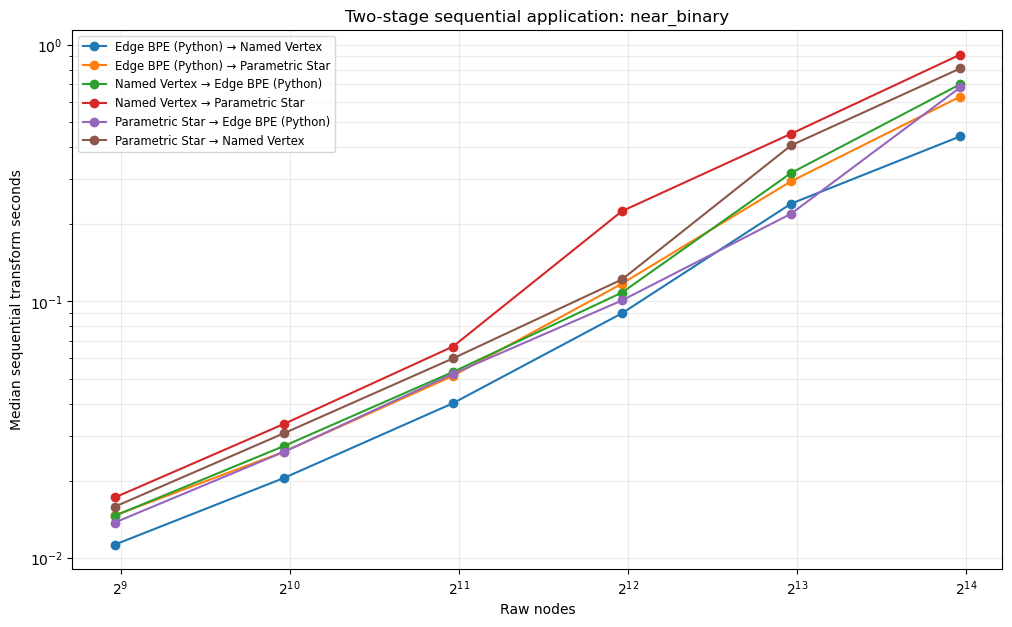

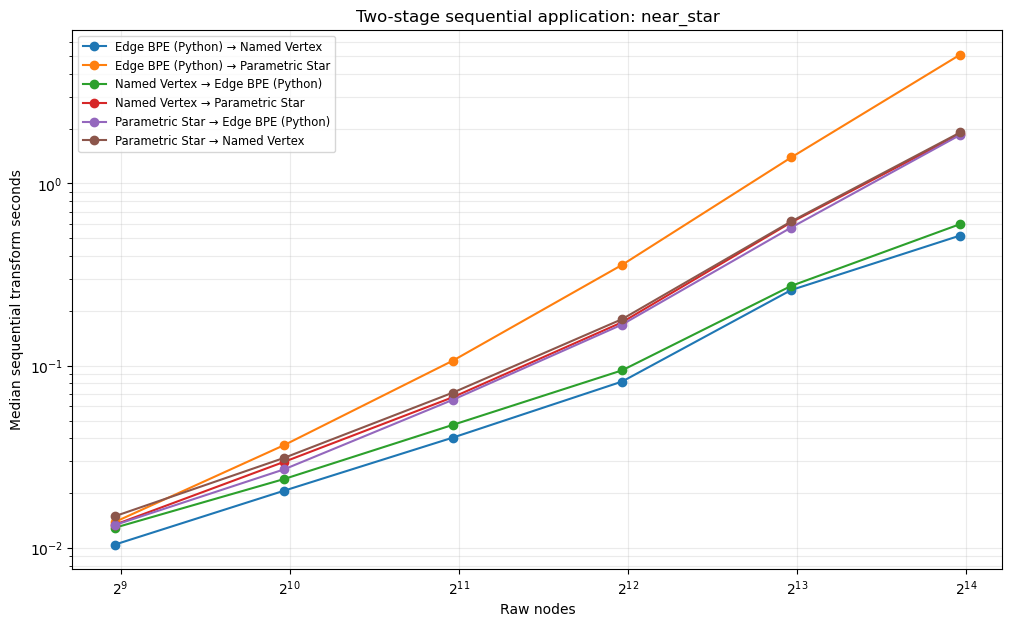

In [6]:
for shape in SHAPES:
    figure = plt.figure(figsize=(12, 7))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for pipeline, group in subset.groupby("pipeline", sort=False):
        group = group.sort_values("n_nodes")
        axis.plot(group["n_nodes"], group["manual_apply_median"], marker="o", label=pipeline)
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Median sequential transform seconds")
    axis.set_title(f"Two-stage sequential application: {shape}")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend(fontsize="small")
    plt.show()

## 6. Sequential application plus exact reverse decode

This is the main pipeline-serving curve after both stages are fitted.


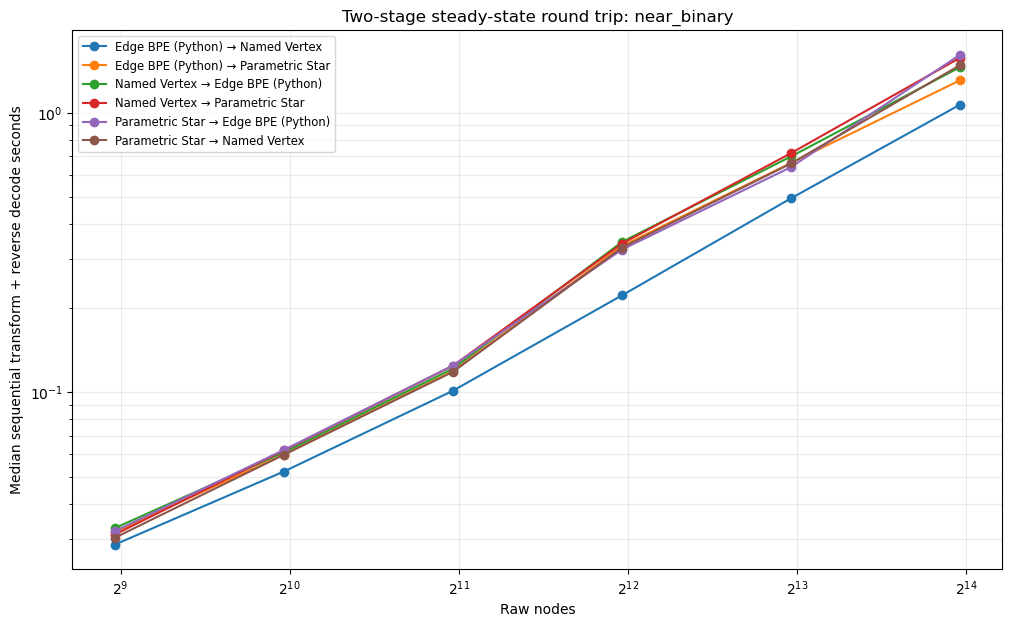

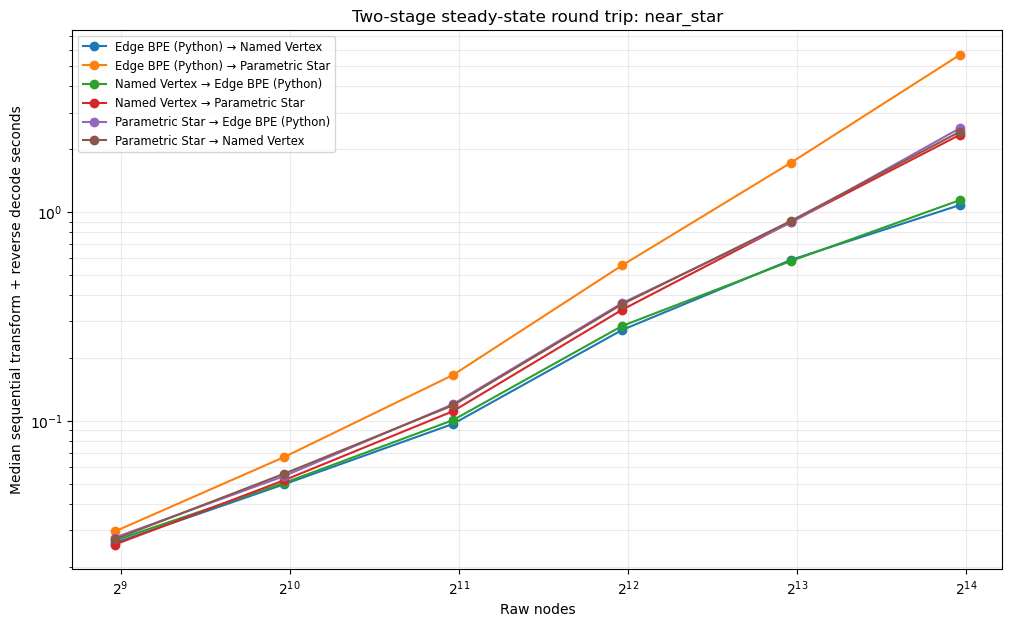

In [7]:
for shape in SHAPES:
    figure = plt.figure(figsize=(12, 7))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for pipeline, group in subset.groupby("pipeline", sort=False):
        group = group.sort_values("n_nodes")
        axis.plot(
            group["n_nodes"],
            group["sequential_roundtrip_median"],
            marker="o",
            label=pipeline,
        )
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Median sequential transform + reverse decode seconds")
    axis.set_title(f"Two-stage steady-state round trip: {shape}")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend(fontsize="small")
    plt.show()

## 7. Pipeline construction plus one subsequent round trip

This includes both fits and the stage-1 transform needed to produce stage-2
training input. It is the relevant total for one-off analysis workflows.


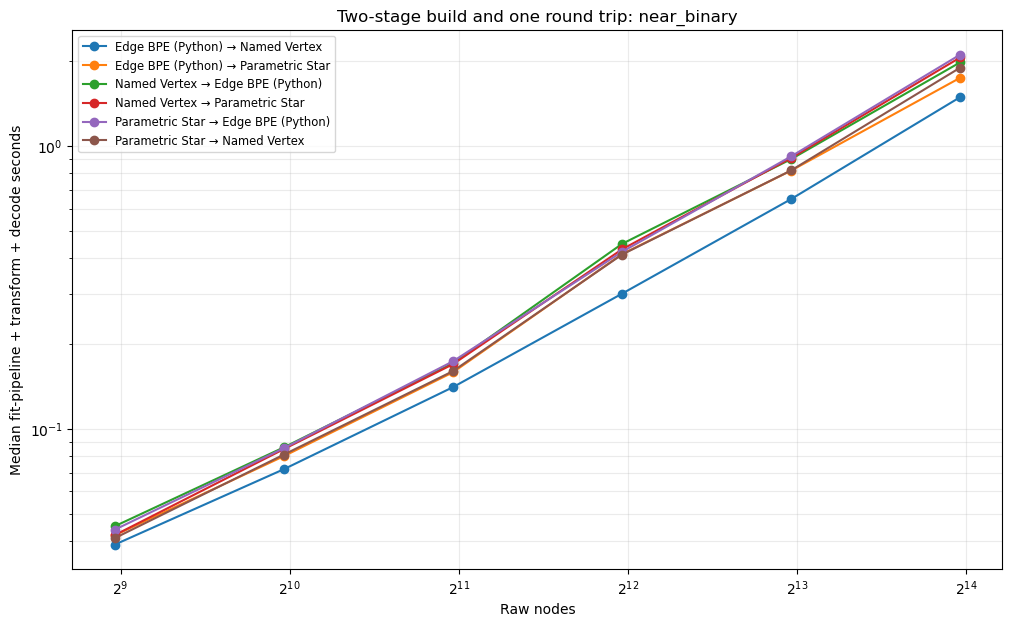

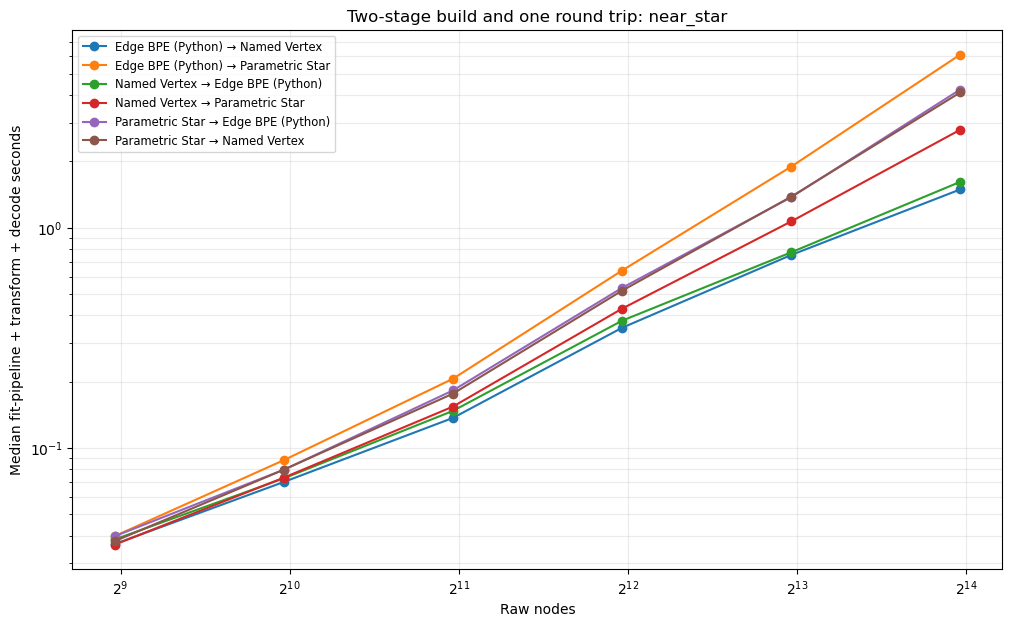

In [8]:
for shape in SHAPES:
    figure = plt.figure(figsize=(12, 7))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for pipeline, group in subset.groupby("pipeline", sort=False):
        group = group.sort_values("n_nodes")
        axis.plot(group["n_nodes"], group["end_to_end_median"], marker="o", label=pipeline)
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Median fit-pipeline + transform + decode seconds")
    axis.set_title(f"Two-stage build and one round trip: {shape}")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend(fontsize="small")
    plt.show()

## 8. `combine(...)` overhead relative to manual calls

The combined artifacts are lazy wrappers around the same atomic stages, so
ratios should remain close to 1. Large systematic deviations deserve
investigation; small deviations are ordinary timer noise and call overhead.


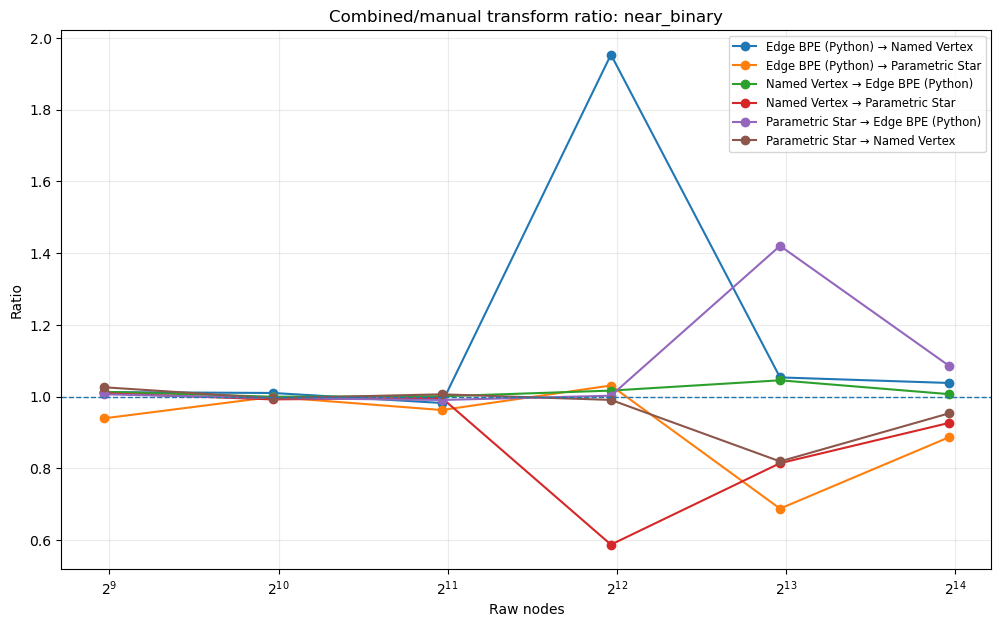

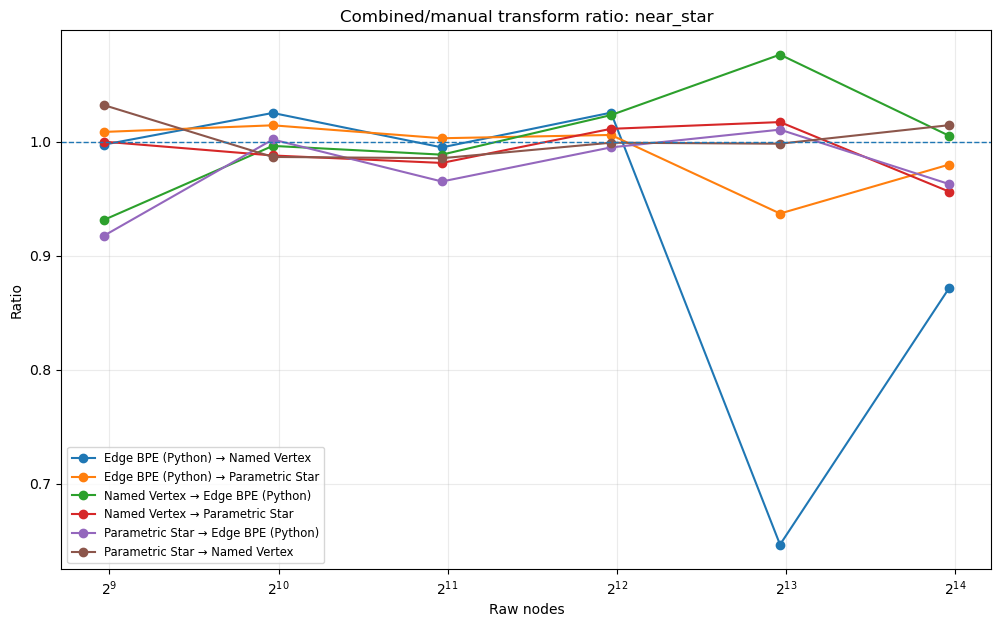

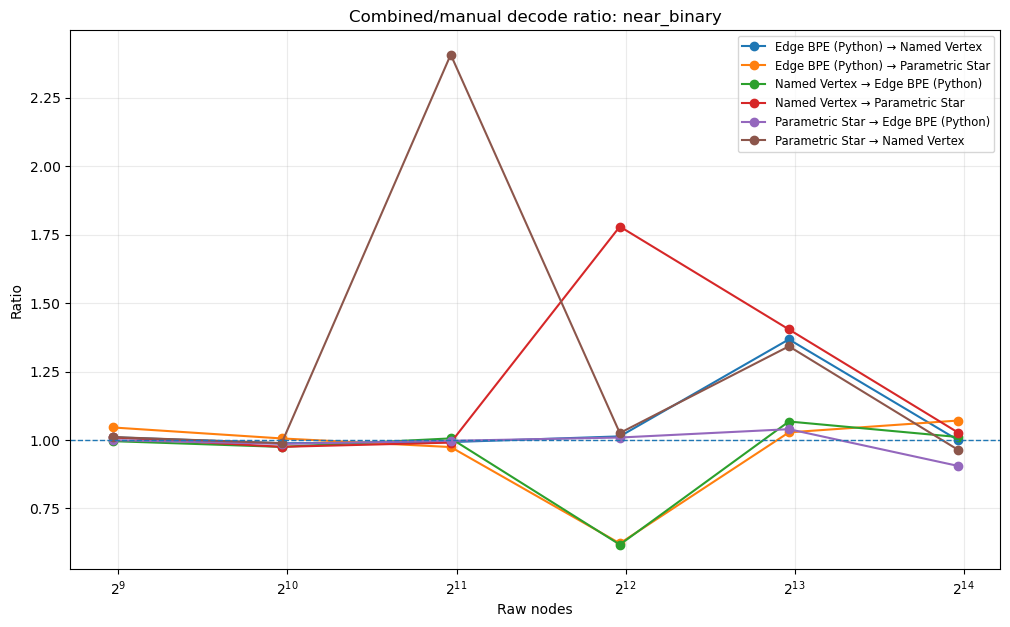

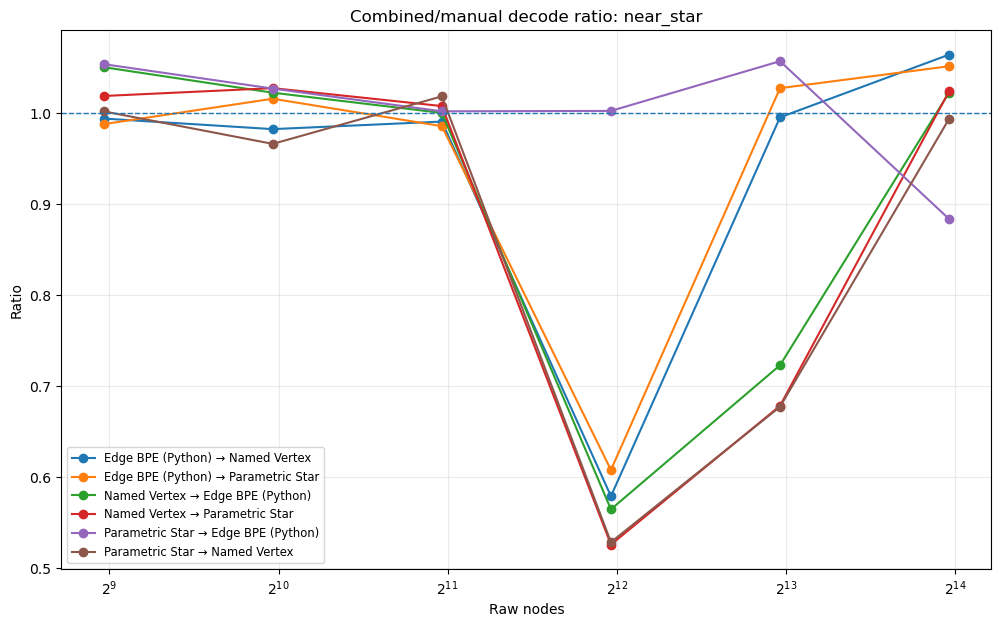

In [9]:
for metric, title in (
    ("combined_apply_ratio", "Combined/manual transform ratio"),
    ("combined_decode_ratio", "Combined/manual decode ratio"),
):
    for shape in SHAPES:
        figure = plt.figure(figsize=(12, 7))
        axis = figure.gca()
        subset = summary_df[summary_df["shape"] == shape]
        for pipeline, group in subset.groupby("pipeline", sort=False):
            group = group.sort_values("n_nodes")
            axis.plot(group["n_nodes"], group[metric], marker="o", label=pipeline)
        axis.axhline(1.0, linestyle="--", linewidth=1)
        axis.set_xscale("log", base=2)
        axis.set_xlabel("Raw nodes")
        axis.set_ylabel("Ratio")
        axis.set_title(f"{title}: {shape}")
        axis.grid(True, which="both", alpha=0.25)
        axis.legend(fontsize="small")
        plt.show()

## 9. Compression and stage activity


In [10]:
activity_columns = [
    "shape",
    "n_nodes",
    "pipeline",
    "stage1_rules",
    "stage2_rules",
    "stage1_nodes",
    "final_nodes",
    "final_compression_ratio",
]
summary_df[activity_columns]

,shape,n_nodes,pipeline,stage1_rules,stage2_rules,stage1_nodes,final_nodes,final_compression_ratio
0,near_binary,500,Edge BPE (Python) → Named Vertex,8.0,1.0,175.0,169.0,0.338000
6,near_binary,1000,Edge BPE (Python) → Named Vertex,8.0,1.0,322.0,322.0,0.322000
12,near_binary,2000,Edge BPE (Python) → Named Vertex,8.0,1.0,672.0,672.0,0.336000
18,near_binary,4000,Edge BPE (Python) → Named Vertex,8.0,1.0,1380.0,1347.0,0.336750
24,near_binary,8000,Edge BPE (Python) → Named Vertex,8.0,1.0,2597.0,2597.0,0.324625
...,...,...,...,...,...,...,...,...
47,near_star,1000,Parametric Star → Named Vertex,1.0,1.0,751.0,252.0,0.252000
53,near_star,2000,Parametric Star → Named Vertex,1.0,1.0,1501.0,502.0,0.251000
59,near_star,4000,Parametric Star → Named Vertex,1.0,1.0,3001.0,1002.0,0.250500
65,near_star,8000,Parametric Star → Named Vertex,1.0,1.0,6001.0,2002.0,0.250250


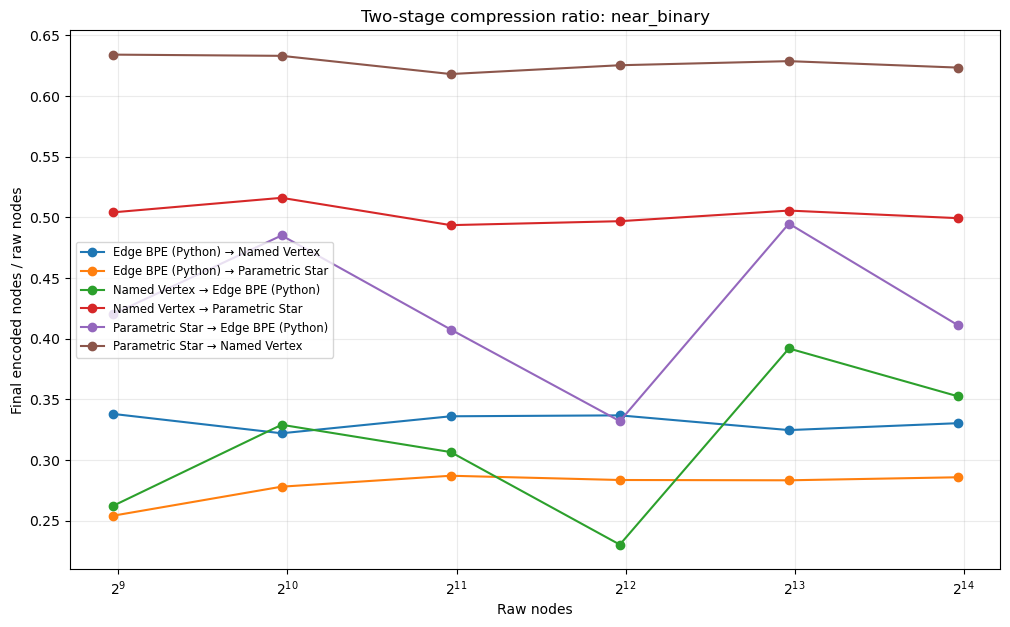

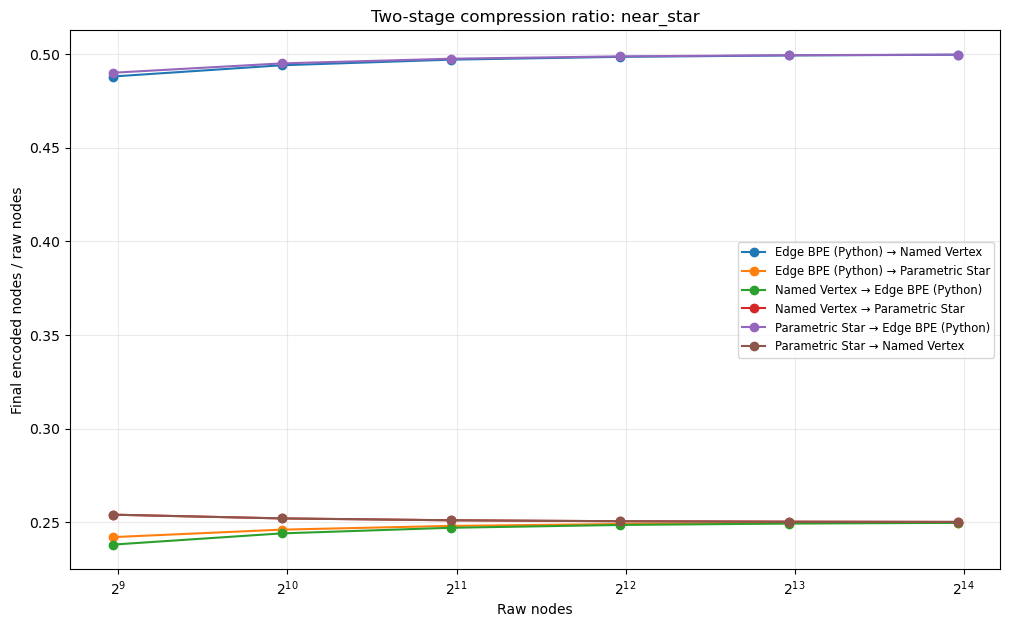

In [11]:
for shape in SHAPES:
    figure = plt.figure(figsize=(12, 7))
    axis = figure.gca()
    subset = summary_df[summary_df["shape"] == shape]
    for pipeline, group in subset.groupby("pipeline", sort=False):
        group = group.sort_values("n_nodes")
        axis.plot(
            group["n_nodes"],
            group["final_compression_ratio"],
            marker="o",
            label=pipeline,
        )
    axis.set_xscale("log", base=2)
    axis.set_xlabel("Raw nodes")
    axis.set_ylabel("Final encoded nodes / raw nodes")
    axis.set_title(f"Two-stage compression ratio: {shape}")
    axis.grid(True, which="both", alpha=0.25)
    axis.legend(fontsize="small")
    plt.show()

## 10. Save reproducible results


In [12]:
if SAVE_RESULTS:
    output_dir = ROOT / "benchmark_results"
    output_dir.mkdir(exist_ok=True)
    backend_tag = BPE_METHOD.removeprefix("bpe_")
    csv_path = output_dir / f"two_stage_pipelines_{backend_tag}_{PROFILE}.csv"
    json_path = output_dir / f"two_stage_pipelines_{backend_tag}_{PROFILE}_metadata.json"
    results_df.to_csv(csv_path, index=False)
    metadata = {
        "environment": ENVIRONMENT,
        "profile": PROFILE,
        "sizes": list(SIZES),
        "repeats": REPEATS,
        "shapes": list(SHAPES),
        "pipelines": [list(pair) for pair in PIPELINES],
        "validate": VALIDATE,
        "bpe_method": BPE_METHOD,
        "pipeline_bpe_num_merges": PIPELINE_BPE_NUM_MERGES,
        "bpe_min_pair_count": BPE_MIN_PAIR_COUNT,
        "numba_cold_warmup_seconds": numba_cold_seconds,
    }
    json_path.write_text(json.dumps(metadata, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    print(csv_path.relative_to(ROOT))
    print(json_path.relative_to(ROOT))

benchmark_results/two_stage_pipelines_python_extended.csv
benchmark_results/two_stage_pipelines_python_extended_metadata.json


## 11. Release interpretation checklist

- All six correctness checks must remain true for every row.
- Manual and combined encoded signatures must match exactly, not merely have the
  same node count.
- Reverse-order stage restoration must recover the exact stage-1 encoded graph
  before raw materialization.
- Inspect stage rule counts and compression ratios for no-op orderings.
- Compare steady-state round-trip curves separately from pipeline-fitting cost.
- Repeat the most important orderings on real project trees and, if Numba is a
  supported release path, rerun with `BPE_METHOD = "bpe_numba"` after explicit
  warm-up.
